In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [12]:
# Carregando a base de dados Iris direto da UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
colunas = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
df = pd.read_csv(url, names=colunas)

# Guardando as respostas reais em uma variável separada (para análises extras no final)
classes_originais = df['species'].values

# Tiramos a coluna 'species' e convertemos para uma matriz Numpy (X)
X = df.drop('species', axis=1).values

print(f"Tamanho da matriz X: {X.shape} -> 150 amostras e 4 características numéricas.")

Tamanho da matriz X: (150, 4) -> 150 amostras e 4 características numéricas.


In [13]:
def kmeans_hardcore(X, k, max_iteracoes=100):
    # 1. Inicialização: escolhendo 'k' pontos aleatórios da base para serem os centróides iniciais
    np.random.seed(42) # Usamos uma semente para garantir que os resultados não mudem a cada execução
    indices_aleatorios = np.random.choice(X.shape[0], k, replace=False)
    centroides = X[indices_aleatorios]
    
    for iteracao in range(max_iteracoes):
        clusters_atribuidos = []
        
        # 2. Atribuição: para cada flor na base, acha o centróide mais próximo
        for ponto in X:
            # Calcula a distância euclidiana da flor para todos os 'k' centróides
            distancias = [np.sqrt(np.sum((ponto - c) ** 2)) for c in centroides]
            
            # np.argmin pega a posição (índice) do menor valor na lista de distâncias
            cluster_mais_proximo = np.argmin(distancias)
            clusters_atribuidos.append(cluster_mais_proximo)
            
        clusters_atribuidos = np.array(clusters_atribuidos)
        
        # 3. Atualização: recalcula a posição dos centróides tirando a média das flores do grupo
        novos_centroides = np.zeros((k, X.shape[1]))
        for i in range(k):
            # Filtra apenas as flores que caíram no cluster 'i'
            pontos_do_cluster = X[clusters_atribuidos == i]
            
            # Se o cluster tiver alguma flor, o novo centróide é a média delas
            if len(pontos_do_cluster) > 0:
                novos_centroides[i] = np.mean(pontos_do_cluster, axis=0)
            else:
                novos_centroides[i] = centroides[i] # Prevenção de erro caso um cluster fique vazio
                
        # 4. Convergência: verifica se os centróides pararam de se mover
        if np.all(centroides == novos_centroides):
            print(f"Algoritmo convergiu na iteração {iteracao + 1}")
            break
            
        centroides = novos_centroides
        
    return clusters_atribuidos, centroides

In [14]:
# Valores de k exigidos pelo enunciado
valores_k = [3, 5]

melhor_k_hardcore = 0
melhor_score_hardcore = -1
melhores_clusters_hardcore = None
melhores_centroides_hardcore = None

print("--- Resultados do K-means Hardcore ---")

for k in valores_k:
    # Marcando o tempo inicial
    inicio = time.time()
    
    # Rodando a nossa função construída do zero
    clusters, centroides = kmeans_hardcore(X, k)
    
    # Marcando o tempo final
    fim = time.time()
    tempo_execucao = fim - inicio
    
    # Calculando a métrica do Sklearn
    score = silhouette_score(X, clusters)
    
    # Salvando o melhor resultado na memória para usarmos no PCA depois
    if score > melhor_score_hardcore:
        melhor_score_hardcore = score
        melhor_k_hardcore = k
        melhores_clusters_hardcore = clusters
        melhores_centroides_hardcore = centroides
        
    print(f"Para k = {k}:")
    print(f"  Silhouette Score: {score:.4f}")
    print(f"  Tempo de execução: {tempo_execucao:.4f} segundos\n")

print(f"O melhor k encontrado foi {melhor_k_hardcore} com um score de {melhor_score_hardcore:.4f}.")

--- Resultados do K-means Hardcore ---
Algoritmo convergiu na iteração 6
Para k = 3:
  Silhouette Score: 0.5526
  Tempo de execução: 0.0140 segundos

Algoritmo convergiu na iteração 5
Para k = 5:
  Silhouette Score: 0.4929
  Tempo de execução: 0.0149 segundos

O melhor k encontrado foi 3 com um score de 0.5526.


--- Visualização dos Clusters com PCA (Hardcore) ---


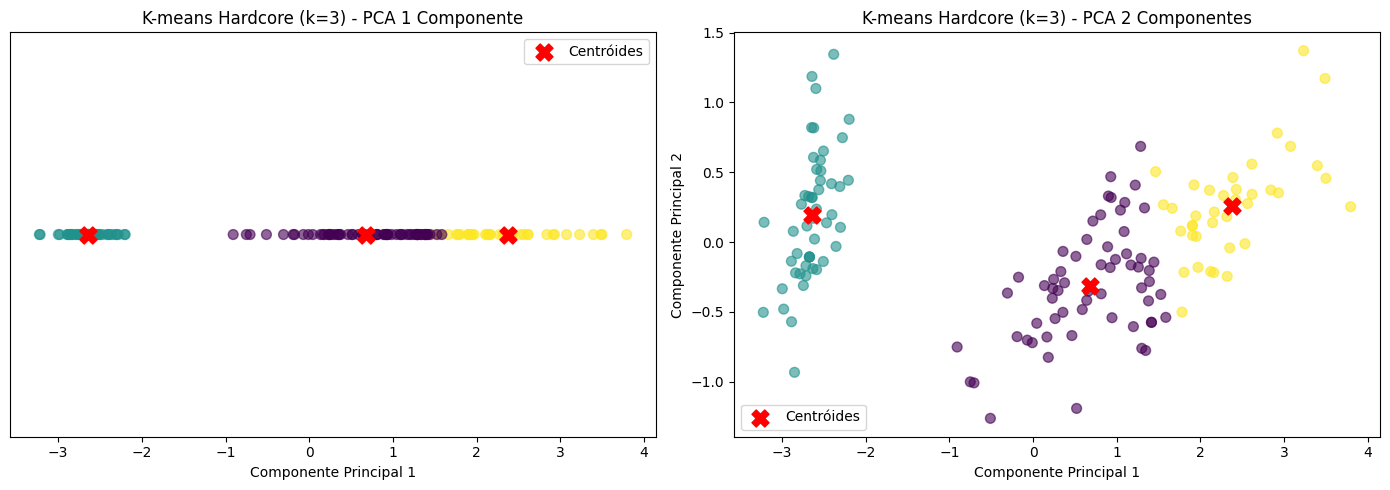

In [15]:
# 1. Aplicando PCA para reduzir as 4 colunas originais para 2 componentes principais
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Precisamos converter a posição dos nossos centróides 4D para o mesmo espaço 2D do PCA
centroides_pca = pca.transform(melhores_centroides_hardcore)

print("--- Visualização dos Clusters com PCA (Hardcore) ---")

# 2. Criando a figura para colocar os dois gráficos lado a lado
plt.figure(figsize=(14, 5))

# --- Gráfico 1: PCA com 1 Componente (1D) ---
plt.subplot(1, 2, 1)
# Como tem só 1 dimensão, cravamos o eixo Y em zero para alinhar os pontos numa linha só
plt.scatter(X_pca[:, 0], np.zeros_like(X_pca[:, 0]), c=melhores_clusters_hardcore, cmap='viridis', s=50, alpha=0.6)
plt.scatter(centroides_pca[:, 0], np.zeros_like(centroides_pca[:, 0]), c='red', marker='X', s=150, label='Centróides')
plt.title(f'K-means Hardcore (k={melhor_k_hardcore}) - PCA 1 Componente')
plt.xlabel('Componente Principal 1')
plt.yticks([]) # Removendo a numeração do eixo Y, pois é irrelevante aqui
plt.legend()

# --- Gráfico 2: PCA com 2 Componentes (2D) ---
plt.subplot(1, 2, 2)
# Aqui usamos as duas componentes geradas (eixo X e eixo Y)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=melhores_clusters_hardcore, cmap='viridis', s=50, alpha=0.6)
plt.scatter(centroides_pca[:, 0], centroides_pca[:, 1], c='red', marker='X', s=150, label='Centróides')
plt.title(f'K-means Hardcore (k={melhor_k_hardcore}) - PCA 2 Componentes')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()

plt.tight_layout()
plt.show()